<a href="https://colab.research.google.com/github/aldoalvaro/ProbStat-AldoTugas4/blob/main/Probabilitas%26Statistika_Tugas_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== TABEL DATA ===
           NIM                Name  KUIS  UTS  UAS  Nilai Grade
0   2455301018         Aldo Alvaro    79   82   90  83.84     A
1       120001            John Doe    85   78   90  84.44     A
2       120005          Jane Smith    92   88   94  91.38     A
3       120017     Michael Johnson    48   65   56  56.41     C
4       120018         Emily Brown    90   85   88  87.65     A
5       120022     Daniel Martinez    75   80   77  77.35    AB
6       120024        Sarah Wilson    88   70   65  74.01     B
7       120025        David Garcia    75   70   75  73.35     B
8       120027         Jessica Lee    95   91   96  94.03     A
9       120034       Matthew Davis    79   84   78  80.30    AB
10      120035  Jennifer Rodriguez    42   48   63  51.33     C
11      120036       Andrew Taylor    53   64   59  58.73     C
12      120038    Amanda Hernandez    91   95   90  91.97     A
13      120039   Christopher Clark    76   81   75  77.30    AB
14      120046  Eliza

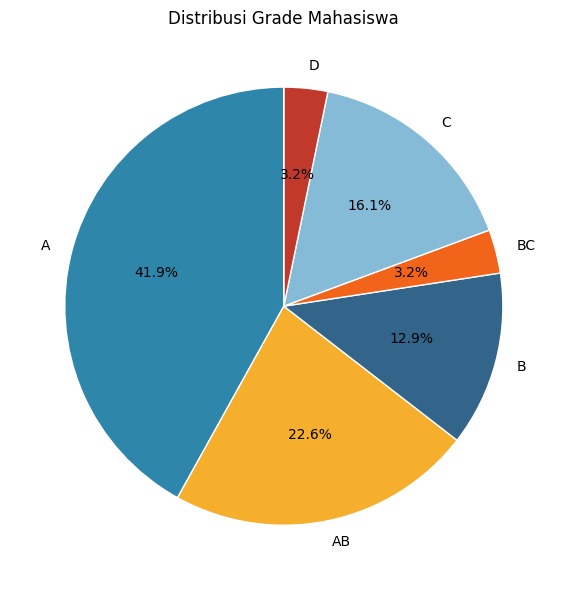

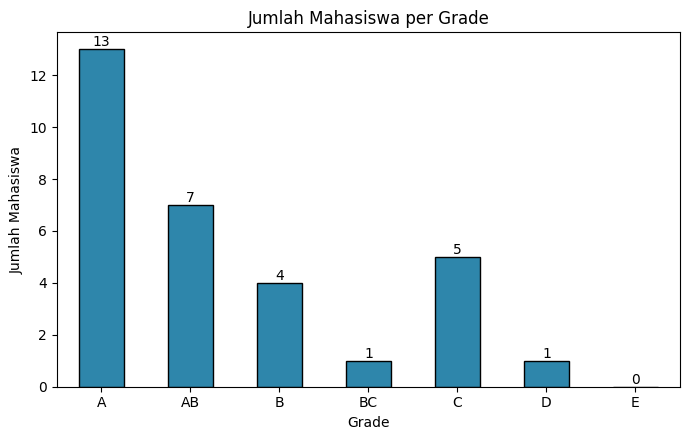

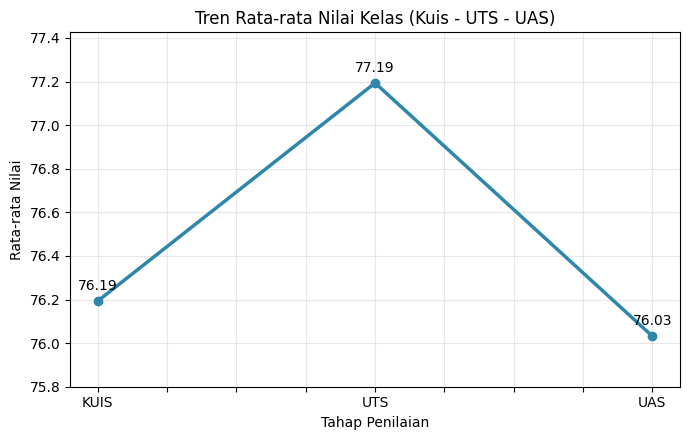

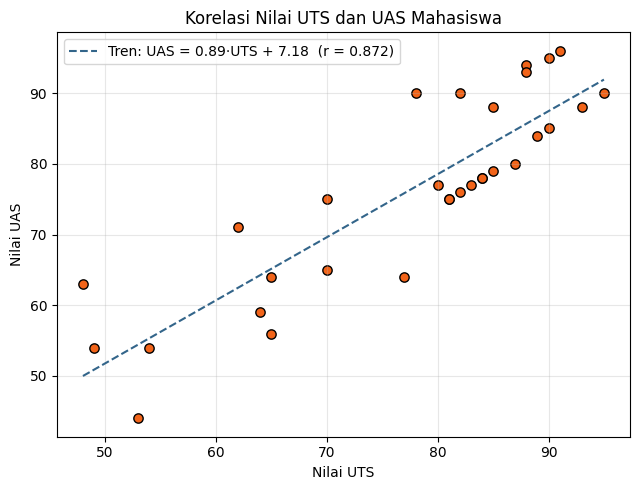


Korelasi UTS-UAS: r = 0.872, r^2 = 0.760, slope = 0.892, intercept = 7.176

=== STATISTIKA DESKRIPTIF NILAI AKHIR ===
count              31.000
mean               76.467
std                13.311
min                46.010
25%                68.800
50%                79.300
75%                86.790
max                94.030
Standard Error      2.391
Median             79.300
Mode               77.300
variance          177.176
range              48.020
skewness           -0.716
kurtosis           -0.437
Name: Nilai, dtype: float64
Semua modus: [77.3, 80.3]

IQR = 17.99 | batas bawah = 41.82 | batas atas = 113.77
Outlier: tidak ada
CV (SD/Mean) = 17.4%

=== RINGKASAN PER KOMPONEN ===
         KUIS    UTS    UAS  Nilai
mean    76.19  77.19  76.03  76.47
median  79.00  82.00  77.00  79.30
std     14.70  13.49  13.80  13.31
min     41.00  48.00  44.00  46.01
max     95.00  95.00  96.00  94.03

Korelasi komponen terhadap Nilai akhir:
KUIS     0.947
UTS      0.947
UAS      0.960
Nilai    1.0

In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PENGORGANISASIAN DATA
# Tabel Data
path = "PenyajianDataProbStatAldo.xlsx"
dataraw = pd.read_excel(path, usecols="B:H")   # kolom B-H saja (yang diambil hanya tabel dari kolom B sampai H saja)
dataraw.columns = ["NIM", "Name", "KUIS", "UTS", "UAS", "Nilai", "Grade"]
print("=== TABEL DATA ===")
print(dataraw)

# Tabel Frekuensi (+ persentase)
datafrq = pd.crosstab(index=dataraw["Grade"], columns="Frekuensi")
datafrq = datafrq.reindex(["A", "AB", "B", "BC", "C", "D", "E"], fill_value=0)
tabel = datafrq.copy()
tabel["Persentase (%)"] = (datafrq["Frekuensi"] / datafrq["Frekuensi"].sum() * 100).round(1)
tabel.loc["Total"] = [datafrq["Frekuensi"].sum(), tabel["Persentase (%)"].sum().round(0)]
tabel["Frekuensi"] = tabel["Frekuensi"].astype(int)
print("\n=== TABEL FREKUENSI ===")
print(tabel)

# PENYAJIAN DATA
warna = ["#2E86AB", "#F6AE2D", "#33658A", "#F26419", "#86BBD8", "#C0392B", "#7F8C8D"]

# 1. Pie Chart - Distribusi Grade Mahasiswa
fig, ax = plt.subplots(figsize=(6, 6))
datafrq.plot(kind="pie", y="Frekuensi", ax=ax, legend=False, colors=warna,
                  startangle=90, wedgeprops={"edgecolor": "white"},
                  autopct=lambda p: f"{p:.1f}%" if p > 0 else "")   # untuk menyembunyikan label 0%
ax.set_ylabel(""); ax.set_title("Distribusi Grade Mahasiswa")
plt.tight_layout(); plt.savefig("pie_chart.png", dpi=150); plt.show()

# 2. Grafik Batang - Jumlah Mahasiswa per Grade
fig, ax = plt.subplots(figsize=(7, 4.5))
datafrq.plot(kind="bar", ax=ax, color=warna, legend=False, edgecolor="black")
ax.set_title("Jumlah Mahasiswa per Grade")
ax.set_xlabel("Grade"); ax.set_ylabel("Jumlah Mahasiswa")
ax.bar_label(ax.containers[0]); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig("grafik_batang.png", dpi=150); plt.show()

# 3. Grafik Garis - Tren rata-rata nilai kelas (Kuis - UTS - UAS)
rata2 = dataraw[["KUIS", "UTS", "UAS"]].mean()
fig, ax = plt.subplots(figsize=(7, 4.5))
rata2.plot(ax=ax, marker="o", color="#2E86AB", linewidth=2.5)
ax.set_title("Tren Rata-rata Nilai Kelas (Kuis - UTS - UAS)")
ax.set_xlabel("Tahap Penilaian"); ax.set_ylabel("Rata-rata Nilai")
ax.grid(alpha=.3); ax.margins(y=0.2)
for i, v in enumerate(rata2):
    ax.annotate(f"{v:.2f}", (i, v), textcoords="offset points", xytext=(0, 8), ha="center")
plt.tight_layout(); plt.savefig("grafik_garis.png", dpi=150); plt.show()

# 4. Scatter Plot - Korelasi nilai UTS dan UAS (+ garis tren)
fig, ax = plt.subplots(figsize=(6.5, 5))
dataraw.plot.scatter(x="UTS", y="UAS", ax=ax, color="#F26419", s=45, edgecolor="black")
m, c = np.polyfit(dataraw["UTS"], dataraw["UAS"], 1)
r = dataraw["UTS"].corr(dataraw["UAS"])
xs = np.array([dataraw["UTS"].min(), dataraw["UTS"].max()])
ax.plot(xs, m * xs + c, "--", color="#33658A", label=f"Tren: UAS = {m:.2f}\u00b7UTS + {c:.2f}  (r = {r:.3f})")
ax.set_title("Korelasi Nilai UTS dan UAS Mahasiswa")
ax.set_xlabel("Nilai UTS"); ax.set_ylabel("Nilai UAS"); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.savefig("scatter_uts_uas.png", dpi=150); plt.show()
print(f"\nKorelasi UTS-UAS: r = {r:.3f}, r^2 = {r**2:.3f}, slope = {m:.3f}, intercept = {c:.3f}")

# STATISTIKA DESKRIPTIF
dataraw["Nilai"] = pd.to_numeric(dataraw["Nilai"], errors="coerce")
dt = dataraw["Nilai"]
stats = dt.describe()
stats["Standard Error"] = dt.sem()
stats["Median"] = dt.median()
stats["Mode"] = dt.mode().iloc[0]
stats["variance"] = dt.var()
stats["range"] = dt.max() - dt.min()
stats["skewness"] = dt.skew()
stats["kurtosis"] = dt.kurtosis()          # excess kurtosis (normal = 0)
print("\n=== STATISTIKA DESKRIPTIF NILAI AKHIR ===")
print(stats.round(3))

print("Semua modus:", dt.mode().tolist())   # data bimodal jika lebih dari satu

# Tambahan: IQR dan deteksi outlier (1,5 x IQR)
q1, q3 = dt.quantile(.25), dt.quantile(.75)
iqr = q3 - q1
bb, ba = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier = dataraw[(dt < bb) | (dt > ba)]
print(f"\nIQR = {iqr:.2f} | batas bawah = {bb:.2f} | batas atas = {ba:.2f}")
print("Outlier:", "tidak ada" if outlier.empty else outlier[["Name", "Nilai"]].to_string(index=False))
print(f"CV (SD/Mean) = {dt.std() / dt.mean() * 100:.1f}%")

# Tambahan: statistik per komponen penilaian
print("\n=== RINGKASAN PER KOMPONEN ===")
print(dataraw[["KUIS", "UTS", "UAS", "Nilai"]].agg(["mean", "median", "std", "min", "max"]).round(2))
print("\nKorelasi komponen terhadap Nilai akhir:")
print(dataraw[["KUIS", "UTS", "UAS", "Nilai"]].corr()["Nilai"].round(3))